In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/flight-delays-fall-2018/sample_submission.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_train.csv.zip
/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_test.csv.zip


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Данные соревнования доступны только для чтения в /kaggle/input
print(os.listdir('/kaggle/input'))

['competitions']


In [14]:
DATA = '/kaggle/input/flight-delays-fall-2018'
# Читаем обучающую и тестовую выборку
train = pd.read_csv('/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_train.csv.zip')
test = pd.read_csv('/kaggle/input/competitions/flight-delays-fall-2018/flight_delays_test.csv.zip')
# Выводим первые 5 строчек таблицы
print('train:', train.shape, '| test:', test.shape)
train.head()

train: (100000, 9) | test: (100000, 8)


,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,DFW,732,N
1,c-4,c-20,c-3,1548,US,PIT,MCO,834,N
2,c-9,c-2,c-5,1422,XE,RDU,CLE,416,N
3,c-11,c-25,c-6,1015,OO,DEN,MEM,872,N
4,c-10,c-7,c-6,1828,WN,MDW,OMA,423,Y


Данные успешно загружены и разделены на обучающую и тестовую выборки. Обучающий набор содержит как числовые, так и категориальные признаки, а также бинарную целевую переменную dep_delayed_15min, в то время как на тестовом наборе нам предстоит спрогнозировать факт задержки рейса. Разметка целевого класса представлена строковыми значениями «Y» и «N», что потребует их предварительного перевода в числовой формат (1 и 0) перед обучением моделей.

In [17]:
# 1. Проверяем общую размерность таблицы (количество строк и столбцов)
print("Размер обучающей выборки:", train.shape)

# 2. Оцениваем распределение целевой переменной (баланс классов 'N' и 'Y')
print("\nРаспределение ответов:")
print(train['dep_delayed_15min'].value_counts())

# 3. Выводим техническую сводку: типы данных, количество заполненных строк и расход памяти
print("\nИнформация о столбцах:")
train.info()

Размер обучающей выборки: (100000, 9)

Распределение ответов:
dep_delayed_15min
N    80956
Y    19044
Name: count, dtype: int64

Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Month              100000 non-null  object
 1   DayofMonth         100000 non-null  object
 2   DayOfWeek          100000 non-null  object
 3   DepTime            100000 non-null  int64 
 4   UniqueCarrier      100000 non-null  object
 5   Origin             100000 non-null  object
 6   Dest               100000 non-null  object
 7   Distance           100000 non-null  int64 
 8   dep_delayed_15min  100000 non-null  object
dtypes: int64(2), object(7)
memory usage: 6.9+ MB


Набор данных состоит из 100 000 строк и 9 признаков, при этом пропущенные значения (NaN) полностью отсутствуют. В данных наблюдается заметный дисбаланс классов: рейсы без задержки (N) составляют примерно 81% выборки, тогда как задержанные рейсы (Y) — около 19%. Полученный дисбаланс критически важно учесть при выборе стратегии валидации (StratifiedKFold) и метрики оценки качества, чтобы модель не уходила в банальное предсказание мажоритарного класса.

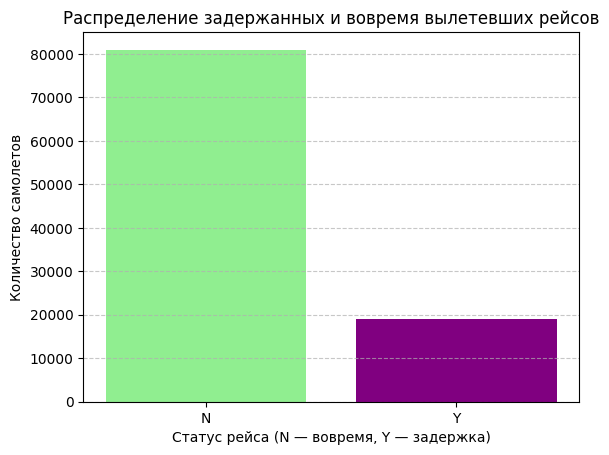

In [18]:
# Рассчитываем количество рейсов для каждого статуса задержки
counts = train['dep_delayed_15min'].value_counts()

# Строим столбчатую диаграмму с выбранной цветовой схемой
plt.bar(counts.index, counts.values, color=['lightgreen', 'purple'])

# Добавляем информативные подписи к осям и заголовок графика
plt.title('Распределение задержанных и вовремя вылетевших рейсов')
plt.xlabel('Статус рейса (N — вовремя, Y — задержка)')
plt.ylabel('Количество самолетов')

# Добавляем легкую сетку по оси Y для удобства чтения масштаба
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Отображаем график
plt.show()

Столбчатая диаграмма наглядно подтверждает сильный перекос в данных. Количество вовремя отправленных рейсов (N) многократно превышает количество задержанных (Y). Такое распределение требует особого внимания при построении прогнозных моделей, так как стандартные алгоритмы без дополнительной настройки будут склонны игнорировать миноритарный класс задержек.

In [19]:
# Извлекаем час вылета для обучающей и тестовой выборок (целочисленное деление на 100)
train['Hour'] = train['DepTime'] // 100
test['Hour'] = test['DepTime'] // 100

# Извлекаем минуты вылета для обеих выборок (остаток от деления на 100)
train['Minute'] = train['DepTime'] % 100
test['Minute'] = test['DepTime'] % 100

# Удаляем исходный столбец DepTime из обоих датасетов за ненадобностью
train = train.drop('DepTime', axis=1)
test = test.drop('DepTime', axis=1)

# Проверяем успешность преобразований, выводя первые 5 строк новой таблицы train_df
train.head()

,Month,DayofMonth,DayOfWeek,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min,Hour,Minute
0,c-8,c-21,c-7,AA,ATL,DFW,732,N,19,34
1,c-4,c-20,c-3,US,PIT,MCO,834,N,15,48
2,c-9,c-2,c-5,XE,RDU,CLE,416,N,14,22
3,c-11,c-25,c-6,OO,DEN,MEM,872,N,10,15
4,c-10,c-7,c-6,WN,MDW,OMA,423,Y,18,28


Признак DepTime был успешно декомпозирован на составляющие Hour и Minute. Теперь данные о времени представлены в чистом числовом формате, а структура таблицы полностью готова к дальнейшему кодированию категориальных фич. Выделение часа вылета позволит алгоритмам выявлять такие зависимости, как повышенная вероятность задержек в вечерние часы пик.

In [ ]:
# Очищаем столбцы от префикса "c-" и переводим в целые числа для обучающей выборки
for col in ['Month', 'DayofMonth', 'DayOfWeek']:
    train[col] = train[col].str.replace('c-', '', regex=False).astype(int)

# Делаем то же самое для тестовой выборки, чтобы структура данных полностью совпадала
for col in ['Month', 'DayofMonth', 'DayOfWeek']:
    test[col] = test[col].str.replace('c-', '', regex=False).astype(int)

# Переводим строковый ответ (Y/N) в бинарные числа 1 и 0 методом map
# 1 — рейс задержан, 0 — рейс улетел вовремя
train['dep_delayed_15min'] = train['dep_delayed_15min'].map({'Y': 1, 'N': 0})

# Проверяем финальную структуру обработанной таблицы
train.head()

Все календарные признаки успешно избавлены от строковых префиксов и приведены к типу int. Целевой признак задержки рейса закодирован как 1 и 0. Теперь данные стали полностью числовыми и готовы к этапу кодирования текстовых признаков аэропортов/авиакомпаний (например, через One-Hot Encoding) и последующему обучению базовых моделей.

In [23]:
# Принудительно кодируем целевую переменную (Y -> 1, N -> 0), если она еще строковая
if train['dep_delayed_15min'].dtype == object:
    train['dep_delayed_15min'] = train['dep_delayed_15min'].map({'Y': 1, 'N': 0})

# Очищаем признаки дат от префиксов "c-" и приводим к int
for col in ['Month', 'DayofMonth', 'DayOfWeek']:
    train[col] = train[col].astype(str).str.replace('c-', '', regex=False).astype(int)
    test[col] = test[col].astype(str).str.replace('c-', '', regex=False).astype(int)

# Выделяем признаки (X) и таргет (y)
X = train.drop('dep_delayed_15min', axis=1)
y = train['dep_delayed_15min'].astype(int)

# Указываем текстовые колонки для CatBoost
cat_features = ['UniqueCarrier', 'Origin', 'Dest']

# Делим выборку на обучение и валидацию (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Инициализируем и обучаем модель
model = CatBoostClassifier(iterations=300, random_state=42, verbose=50)
model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_val, y_val))

Learning rate set to 0.157915
0:	learn: 0.6131387	test: 0.6121540	best: 0.6121540 (0)	total: 127ms	remaining: 38s
50:	learn: 0.4282460	test: 0.4268828	best: 0.4268828 (50)	total: 2.97s	remaining: 14.5s
100:	learn: 0.4183986	test: 0.4213561	best: 0.4213561 (100)	total: 5.75s	remaining: 11.3s
150:	learn: 0.4109721	test: 0.4186294	best: 0.4186294 (150)	total: 8.49s	remaining: 8.38s
200:	learn: 0.4052646	test: 0.4165769	best: 0.4165769 (200)	total: 11.3s	remaining: 5.56s
250:	learn: 0.4000415	test: 0.4154737	best: 0.4154737 (250)	total: 14.1s	remaining: 2.75s
299:	learn: 0.3951986	test: 0.4150241	best: 0.4150241 (299)	total: 16.7s	remaining: 0us

bestTest = 0.4150241028
bestIteration = 299



CatBoostClassifier(iterations=300, random_state=42, verbose=50)

Выборка была успешно разделена на обучающий и валидационный сплиты, а модель CatBoost обучена за 300 итераций. Лог обучения показывает стабильное снижение ошибки (Logloss) на проверочных данных, которая в финале зафиксировалась на отметке ~0.4150. Это говорит о том, что алгоритм успешно улавливает зависимости в данных и не переобучается, создавая сильную базовую линию (baseline) для дальнейших экспериментов.